### Analyse Exploiratoire des données

Importation des librairies

In [200]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [201]:
# Ajoutons les paths
#BASE_PATH = '/content/drive/MyDrive/P4'

#sirh = pd.read_csv(f'{BASE_PATH}/extrait_sirh.csv')
#eval = pd.read_csv(f'{BASE_PATH}/extrait_eval.csv')
#sondage = pd.read_csv(f'{BASE_PATH}/extrait_sondage.csv')

### Importations des fichiers

In [202]:
#from google.colab import drive
#drive.mount('/content/drive')

eval = pd.read_csv("..\Dataset\extrait_eval.csv")
eval.head().T

,0,1,2,3,4
satisfaction_employee_environnement,2,3,4,4,1
note_evaluation_precedente,3,2,2,3,3
niveau_hierarchique_poste,2,2,1,1,1
satisfaction_employee_nature_travail,4,2,3,3,2
satisfaction_employee_equipe,1,4,2,3,4
satisfaction_employee_equilibre_pro_perso,1,3,3,3,3
eval_number,E_1,E_2,E_4,E_5,E_7
note_evaluation_actuelle,3,4,3,3,3
heure_supplementaires,Oui,Non,Oui,Oui,Non
augementation_salaire_precedente,11 %,23 %,15 %,11 %,12 %


### Verification du nombre de ligne et de colonne

In [203]:
print('Explorons quelques informations essentielles')
print('---------------------------------------------')
print('Nombre de ligne ', eval.shape[0])
print('---------------------------------------------')
print('Nombre de colonne', eval.shape[1])
print('---------------------------------------------')
print('Nombre de doublons', eval.duplicated().sum())
print('---------------------------------------------')
print('Valeurs manquantes', eval.isnull().sum())

Explorons quelques informations essentielles
---------------------------------------------
Nombre de ligne  1470
---------------------------------------------
Nombre de colonne 10
---------------------------------------------
Nombre de doublons 0
---------------------------------------------
Valeurs manquantes satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
eval_number                                  0
note_evaluation_actuelle                     0
heure_supplementaires                        0
augementation_salaire_precedente             0
dtype: int64


In [204]:
eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

In [205]:
eval.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


* Identifier et nettoyer les colonnes qui correspondent à des informations quantitatives ou qualitatives.

In [206]:
eval.dtypes

satisfaction_employee_environnement           int64
note_evaluation_precedente                    int64
niveau_hierarchique_poste                     int64
satisfaction_employee_nature_travail          int64
satisfaction_employee_equipe                  int64
satisfaction_employee_equilibre_pro_perso     int64
eval_number                                  object
note_evaluation_actuelle                      int64
heure_supplementaires                        object
augementation_salaire_precedente             object
dtype: object

* Prendre l’habitude d’utiliser la méthode .apply() de Pandas pour nettoyer vos colonnes.

In [207]:
eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [208]:
eval['eval_number'].value_counts()

eval_number
E_1       1
E_1391    1
E_1389    1
E_1387    1
E_1383    1
         ..
E_659     1
E_657     1
E_656     1
E_655     1
E_2068    1
Name: count, Length: 1470, dtype: int64

* Les colonnes que nous allons nettoyer sont :
* heure_supplemenaires : convertissons oui et non en booléan (0,1)
* augmentation_salaire_precedente : convertissons la colonne en nombre

In [209]:
# La colonne eval_number doit être nettoyer pour enlever les E_
eval['eval_number'] = eval['eval_number'].str.replace('E_', '').astype(int)

In [210]:
eval['eval_number']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: eval_number, Length: 1470, dtype: int64

In [211]:
# Avant
eval['heure_supplementaires'].value_counts()

heure_supplementaires
Non    1054
Oui     416
Name: count, dtype: int64

In [212]:
# Après
eval["heure_supplementaires"] = eval["heure_supplementaires"].apply(
    lambda x: 1 if x == "Oui" else 0
)

In [213]:
eval['heure_supplementaires'].value_counts()

heure_supplementaires
0    1054
1     416
Name: count, dtype: int64

In [214]:
# Avant
eval['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
11 %    210
13 %    209
14 %    201
12 %    198
15 %    101
18 %     89
17 %     82
16 %     78
19 %     76
22 %     56
20 %     55
21 %     48
23 %     28
24 %     21
25 %     18
Name: count, dtype: int64

In [215]:
# Après
eval["augementation_salaire_precedente"] = eval["augementation_salaire_precedente"].apply(
    lambda x: float(x.replace("%",""))
)

In [216]:
eval['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
11.0    210
13.0    209
14.0    201
12.0    198
15.0    101
18.0     89
17.0     82
16.0     78
19.0     76
22.0     56
20.0     55
21.0     48
23.0     28
24.0     21
25.0     18
Name: count, dtype: int64

* Commencer par des statistiques descriptives simples sur chacun des trois fichiers.

In [217]:
eval.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,1024.865306,3.153741,0.282993,15.209524
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,602.024335,0.360824,0.450606,3.659938
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,11.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,491.250000,3.000000,0.000000,12.000000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,1020.500000,3.000000,0.000000,14.000000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,1555.750000,3.000000,1.000000,18.000000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,2068.000000,4.000000,1.000000,25.000000


### visualisations

### Conclusion

In [218]:
eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   eval_number                                1470 non-null   int64  
 7   note_evaluation_actuelle                   1470 non-null   int64  
 8   heure_supplementaires                      1470 non-null   int64  
 9   augementation_salaire_precedente           1470 non-null   float64
dtypes: float64(1), int64(9)


* Nous avons 1470 lignes
* Nous avons 10 colonnes
* Nous avons 0 doublons et 0 valeurs manquantes
* Colonne clé du jeu de donnée : eval_number qui à la forme d'une clé avec un enregistrement unique les autres sont des mésures

### Importation du fichier extrait_sirh

In [219]:
#from google.colab import drive
#drive.mount('/content/drive')

sirh = pd.read_csv("..\Dataset\extrait_sirh.csv")
sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [220]:
sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


### Verification de quelques informations

In [221]:
print('Explorons quelques informations essentielles')
print('---------------------------------------------')
print('Nombre de ligne ', sirh.shape[0])
print('---------------------------------------------')
print('Nombre de colonne', sirh.shape[1])
print('---------------------------------------------')
print('Nombre de doublons', sirh.duplicated().sum())
print('---------------------------------------------')
print('Valeurs manquantes', sirh.isnull().sum())

Explorons quelques informations essentielles
---------------------------------------------
Nombre de ligne  1470
---------------------------------------------
Nombre de colonne 12
---------------------------------------------
Nombre de doublons 0
---------------------------------------------
Valeurs manquantes id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement                       0
poste                             0
nombre_experiences_precedentes    0
nombre_heures_travailless         0
annee_experience_totale           0
annees_dans_l_entreprise          0
annees_dans_le_poste_actuel       0
dtype: int64


In [222]:
# Mehode 1
for col in sirh.columns:
    print(f"Colonne : {col}")
    print(sirh[col].value_counts())
    print("--------------")

Colonne : id_employee
id_employee
1       1
1391    1
1389    1
1387    1
1383    1
       ..
659     1
657     1
656     1
655     1
2068    1
Name: count, Length: 1470, dtype: int64
--------------
Colonne : age
age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
33    58
38    58
40    57
37    50
27    48
28    48
42    46
39    42
45    41
41    40
26    39
44    33
46    33
43    32
50    30
25    26
24    26
49    24
47    24
55    22
51    19
53    19
48    19
54    18
52    18
22    16
56    14
23    14
58    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: count, dtype: int64
--------------
Colonne : genre
genre
M    882
F    588
Name: count, dtype: int64
--------------
Colonne : revenu_mensuel
revenu_mensuel
2342     4
6142     3
2741     3
2559     3
2610     3
        ..
7104     1
2773     1
19513    1
3447     1
4404     1
Name: count, Length: 1349, dtype: int64
--------------
Colonne : statut_marital
statut_marital
Marié(e)       673

In [223]:
sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


### Identifions et nettoyons les colonnes numeriques et catégorielles

In [224]:
# Avant
sirh['genre'].value_counts()

genre
M    882
F    588
Name: count, dtype: int64

In [225]:
# Après
sirh['genre'] = sirh['genre'].apply(
    lambda x: x.strip().lower()
)

In [226]:
sirh['genre'].value_counts()

genre
m    882
f    588
Name: count, dtype: int64

In [227]:
# Avant
sirh['statut_marital'].value_counts()

statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

In [228]:
# Après
sirh['statut_marital'] = sirh['statut_marital'].apply(
    lambda x : x.strip().lower()
)

In [229]:
sirh['statut_marital'].value_counts()

statut_marital
marié(e)       673
célibataire    470
divorcé(e)     327
Name: count, dtype: int64

In [230]:
# Avant
sirh['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [231]:
# Après
sirh['departement'] = sirh['departement'].apply(
    lambda x : x.strip().lower()
)

In [232]:
sirh['departement'].value_counts()

departement
consulting             961
commercial             446
ressources humaines     63
Name: count, dtype: int64

In [233]:
# Avant
sirh['poste'].value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [234]:
# Après
sirh['poste'] = sirh['poste'].apply(
    lambda x : x.strip().lower()
)

In [235]:
sirh['poste'].value_counts()

poste
cadre commercial           326
assistant de direction     292
consultant                 259
tech lead                  145
manager                    131
senior manager             102
représentant commercial     83
directeur technique         80
ressources humaines         52
Name: count, dtype: int64

### Visualisations

In [236]:
sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


<Axes: xlabel='age', ylabel='revenu_mensuel'>

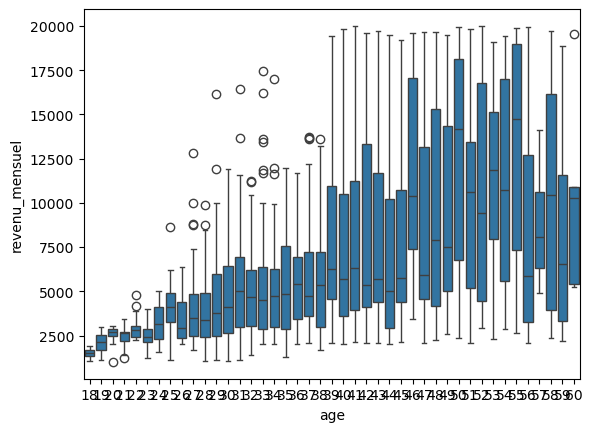

In [237]:
# quanti vs quali
sns.boxplot(x="age", y="revenu_mensuel", data=sirh)

<Axes: xlabel='age', ylabel='revenu_mensuel'>

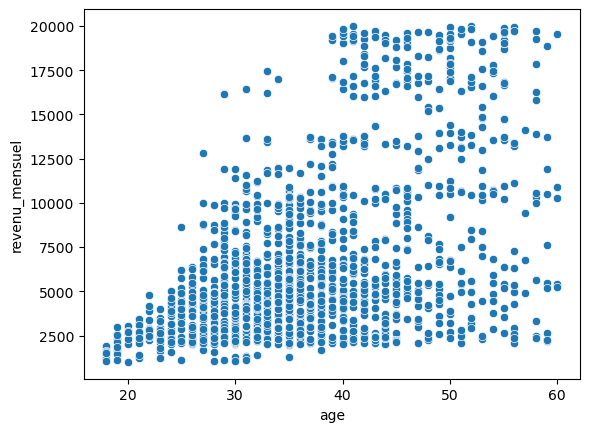

In [238]:
sns.scatterplot(x="age", y="revenu_mensuel", data=sirh)

<Axes: xlabel='age', ylabel='genre'>

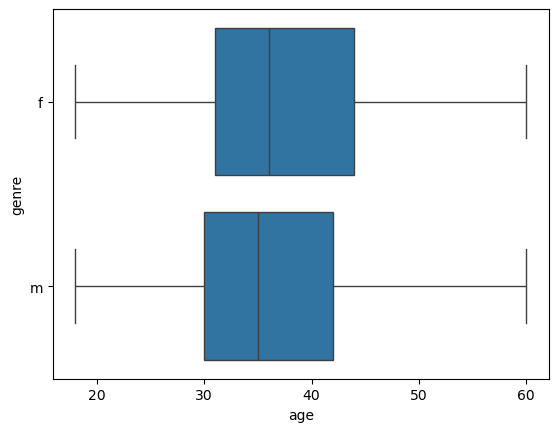

In [239]:
sns.boxplot(x = "age", y = "genre", data = sirh )

<Axes: xlabel='age', ylabel='genre'>

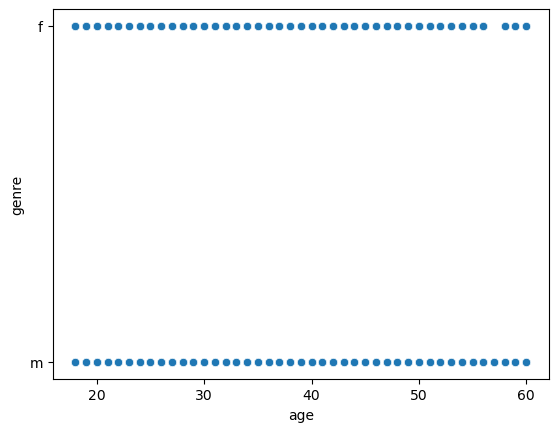

In [240]:
sns.scatterplot(x = "age", y = "genre", data = sirh )

In [241]:
sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


<Axes: xlabel='revenu_mensuel', ylabel='statut_marital'>

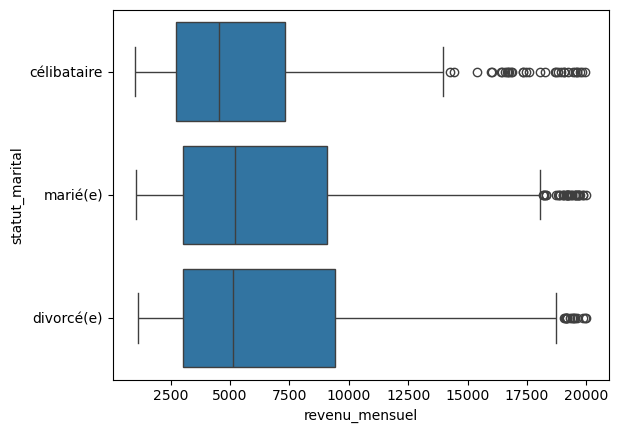

In [242]:
sns.boxplot(x = 'revenu_mensuel', y = 'statut_marital', data = sirh)

<Axes: xlabel='annees_dans_l_entreprise', ylabel='departement'>

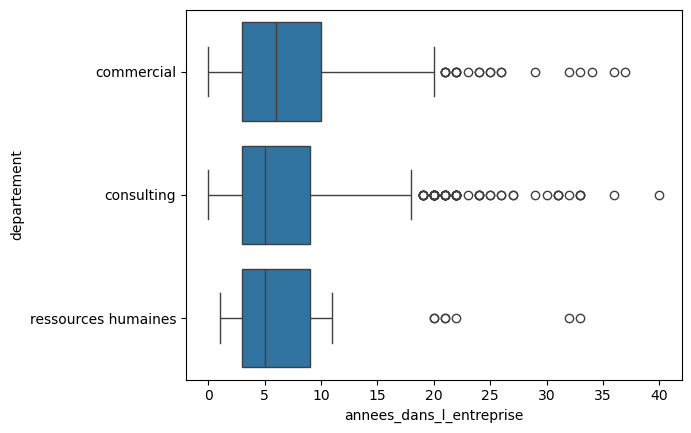

In [243]:
sns.boxplot(x ="annees_dans_l_entreprise", y = "departement", data = sirh)

### Conclusion

* Nous avons 1470 lignes
* Nous avons 12 colonnes
* Nous avons 0 doublons et 0 valeurs manquantes
* Colonne clé du jeu de donnée : id_employe qui à la forme d'une clé avec un enregistrement unique

### Chargement du fichier sondage

In [244]:
#from google.colab import drive
#drive.mount('/content/drive')

sond= pd.read_csv("..\Dataset\extrait_sondage.csv")
sond.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [245]:
sond['code_sondage'].value_counts()

code_sondage
1       1
1391    1
1389    1
1387    1
1383    1
       ..
659     1
657     1
656     1
655     1
2068    1
Name: count, Length: 1470, dtype: int64

In [246]:
print('Explorons quelques informations essentielles')
print('---------------------------------------------')
print('Nombre de ligne ', sond.shape[0])
print('---------------------------------------------')
print('Nombre de colonne', sond.shape[1])
print('---------------------------------------------')
print('Nombre de doublons', sond.duplicated().sum())
print('---------------------------------------------')
print('Valeurs manquantes', sond.isnull().sum())

Explorons quelques informations essentielles
---------------------------------------------
Nombre de ligne  1470
---------------------------------------------
Nombre de colonne 12
---------------------------------------------
Nombre de doublons 0
---------------------------------------------
Valeurs manquantes a_quitte_l_entreprise                  0
nombre_participation_pee               0
nb_formations_suivies                  0
nombre_employee_sous_responsabilite    0
code_sondage                           0
distance_domicile_travail              0
niveau_education                       0
domaine_etude                          0
ayant_enfants                          0
frequence_deplacement                  0
annees_depuis_la_derniere_promotion    0
annes_sous_responsable_actuel          0
dtype: int64


* Identifer et nettoyer les colonnes qui correspondent à des informations catégorielles ou quantitatives
* Prendre l'habitude d'utiliser la méthode .apply de pandas pour nettoyer les colonnes

In [247]:
sond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [248]:
# Avant
sond['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

In [249]:
# Après
sond["a_quitte_l_entreprise"] = sond["a_quitte_l_entreprise"].apply(
    lambda x: 1 if x == "Oui" else 0
)

In [250]:
sond['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64

In [251]:
sond.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,0,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,1,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,0,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,0,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [252]:
sond['domaine_etude'] = sond['domaine_etude'].apply(
    lambda x : x.strip().lower()
)


In [253]:
sond['ayant_enfants'] = sond['ayant_enfants'].apply(
    lambda x : x.strip().lower()
)

In [254]:
sond['frequence_deplacement'] = sond['frequence_deplacement'].apply(
    lambda x : x.strip().lower()
)

In [255]:
sond.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,0,0,1,1,1,2,infra & cloud,y,occasionnel,0,5
1,0,1,3,1,2,8,1,infra & cloud,y,frequent,1,7
2,1,0,3,1,4,2,2,autre,y,occasionnel,0,0
3,0,0,3,1,5,3,4,infra & cloud,y,frequent,3,0
4,0,1,3,1,7,2,1,transformation digitale,y,occasionnel,2,2


In [256]:
sond['ayant_enfants'].value_counts()

ayant_enfants
y    1470
Name: count, dtype: int64

In [257]:
sond['code_sondage'].unique()

array([   1,    2,    4, ..., 2064, 2065, 2068], shape=(1470,))

### Visualisations

In [258]:
sond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   int64 
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

<Axes: xlabel='a_quitte_l_entreprise', ylabel='domaine_etude'>

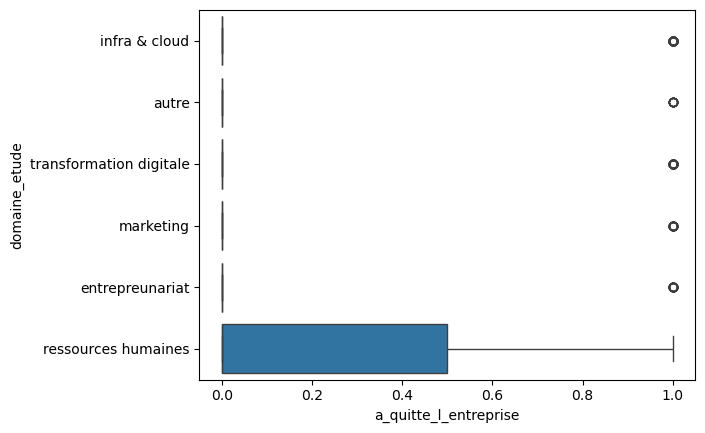

In [259]:
sns.boxplot(x= "a_quitte_l_entreprise", y ="domaine_etude", data = sond)

### Conclusions

* Nous avons 1470 lignes
* Nous avons 12 colonnes
* Nous avons 0 doublons et 0 valeurs manquantes
* Colonne clé du jeu de donnée : code_sondage qui à la forme d'une clé avec un enregistrement unique

In [260]:
eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   eval_number                                1470 non-null   int64  
 7   note_evaluation_actuelle                   1470 non-null   int64  
 8   heure_supplementaires                      1470 non-null   int64  
 9   augementation_salaire_precedente           1470 non-null   float64
dtypes: float64(1), int64(9)


In [261]:
sirh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [262]:
sond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   int64 
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [263]:
sirh["id_employee"].unique()

array([   1,    2,    4, ..., 2064, 2065, 2068], shape=(1470,))

In [264]:
sond['code_sondage'].unique()

array([   1,    2,    4, ..., 2064, 2065, 2068], shape=(1470,))

In [265]:
eval['eval_number'].unique()

array([   1,    2,    4, ..., 2064, 2065, 2068], shape=(1470,))

* Après observations nous constatons que les colonnes qui nous permettront de faire la jointure sont : id_employee, eval_number, code_sondage
* Mais pour effectuer une jointure nous devons avoir une colonne identique donc pour ça nous allons effectuer un rename sur les deux colonnes pour leur ramener à id_employee

In [266]:
# Avant rename
eval['eval_number']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: eval_number, Length: 1470, dtype: int64

In [267]:
# Avant rename
eval['eval_number']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: eval_number, Length: 1470, dtype: int64

In [268]:
# Après rename
eval = eval.rename(columns={"eval_number": "id_employee"})
eval['id_employee']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: id_employee, Length: 1470, dtype: int64

In [269]:
# Avant rename
sond['code_sondage']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: code_sondage, Length: 1470, dtype: int64

In [270]:
# Après rename
sond = sond.rename(columns={"code_sondage": "id_employee"})

In [271]:
sond['id_employee']

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: id_employee, Length: 1470, dtype: int64

### Jointures des 3 fichiers

* La colonne de jointure est id_employee

In [272]:
df = sirh.merge(eval, on= "id_employee", how ="inner", validate = "one_to_one")
df = df.merge(sond, on= "id_employee", how="inner", validate = "one_to_one")

In [273]:
df

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,f,5993,célibataire,commercial,cadre commercial,8,80,8,...,0,0,1,1,2,infra & cloud,y,occasionnel,0,5
1,2,49,m,5130,marié(e),consulting,assistant de direction,1,80,10,...,1,3,1,8,1,infra & cloud,y,frequent,1,7
2,4,37,m,2090,célibataire,consulting,consultant,6,80,7,...,0,3,1,2,2,autre,y,occasionnel,0,0
3,5,33,f,2909,marié(e),consulting,assistant de direction,1,80,8,...,0,3,1,3,4,infra & cloud,y,frequent,3,0
4,7,27,m,3468,marié(e),consulting,consultant,9,80,6,...,1,3,1,2,1,transformation digitale,y,occasionnel,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,36,m,2571,marié(e),consulting,consultant,4,80,17,...,1,3,1,23,2,transformation digitale,y,frequent,0,3
1466,2062,39,m,9991,marié(e),consulting,manager,4,80,9,...,1,5,1,6,1,transformation digitale,y,occasionnel,1,7
1467,2064,27,m,6142,marié(e),consulting,tech lead,1,80,6,...,1,0,1,4,3,infra & cloud,y,occasionnel,0,3
1468,2065,49,m,5390,marié(e),commercial,cadre commercial,2,80,17,...,0,3,1,2,3,transformation digitale,y,frequent,0,8


In [274]:
df.isnull().sum()
#df.info()

id_employee                                  0
age                                          0
genre                                        0
revenu_mensuel                               0
statut_marital                               0
departement                                  0
poste                                        0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
note_evaluation_actuelle                     0
heure_supplementaires                        0
augementation_salaire_precedente             0
a_quitte_l_en

### Conclusion

### Etape 2
* Préparation de la donnée pour la modélisation

In [275]:
cat = df.select_dtypes(include=['object'])

In [276]:
len(cat.nunique())

7

In [277]:
num = df.select_dtypes(include=['int64','float64'])

In [278]:
len(num.nunique())

25

In [279]:
corr_pearson = num.corr()
corr_pearson.T

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,...,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
id_employee,1.000000,-0.010145,-0.014829,-0.001251,NaN,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,...,-0.024037,-0.012944,-0.010577,0.062227,0.023603,NaN,0.032916,0.042070,-0.009019,-0.009197
age,-0.010145,1.000000,0.497855,0.299635,NaN,0.680381,0.311309,0.212901,0.010146,0.029820,...,0.028062,0.003634,-0.159205,0.037510,-0.019621,NaN,-0.001686,0.208034,0.216513,0.202089
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,NaN,0.772893,0.514285,0.363818,-0.006259,-0.015271,...,0.006089,-0.027269,-0.159840,0.005408,-0.021736,NaN,-0.017014,0.094961,0.344978,0.344079
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,NaN,0.237639,-0.118421,-0.090754,0.012594,0.015012,...,-0.020786,-0.010238,0.043494,0.030075,-0.066054,NaN,-0.029251,0.126317,-0.036814,-0.110319
nombre_heures_travailless,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee_experience_totale,-0.014365,0.680381,0.772893,0.237639,NaN,1.000000,0.628133,0.460365,-0.002693,-0.005533,...,0.012754,-0.020608,-0.171063,0.010136,-0.035662,NaN,0.004628,0.148280,0.404858,0.459188
annees_dans_l_entreprise,-0.011240,0.311309,0.514285,-0.118421,NaN,0.628133,1.000000,0.758754,0.001458,-0.021355,...,-0.011687,-0.035991,-0.134392,0.015058,0.003569,NaN,0.009508,0.069114,0.618409,0.769212
annees_dans_le_poste_actuel,-0.008416,0.212901,0.363818,-0.090754,NaN,0.460365,0.758754,1.000000,0.018007,0.008717,...,-0.029758,-0.001520,-0.160545,0.050818,-0.005738,NaN,0.018845,0.060236,0.548056,0.714365
satisfaction_employee_environnement,0.017621,0.010146,-0.006259,0.012594,NaN,-0.002693,0.001458,0.018007,1.000000,-0.008278,...,0.070132,-0.031701,-0.103369,0.003432,-0.019359,NaN,-0.016075,-0.027128,0.016194,-0.004999
note_evaluation_precedente,-0.006888,0.029820,-0.015271,0.015012,NaN,-0.005533,-0.021355,0.008717,-0.008278,1.000000,...,-0.003507,-0.017205,-0.130016,0.021523,-0.015338,NaN,0.008783,0.042438,-0.024184,0.025976


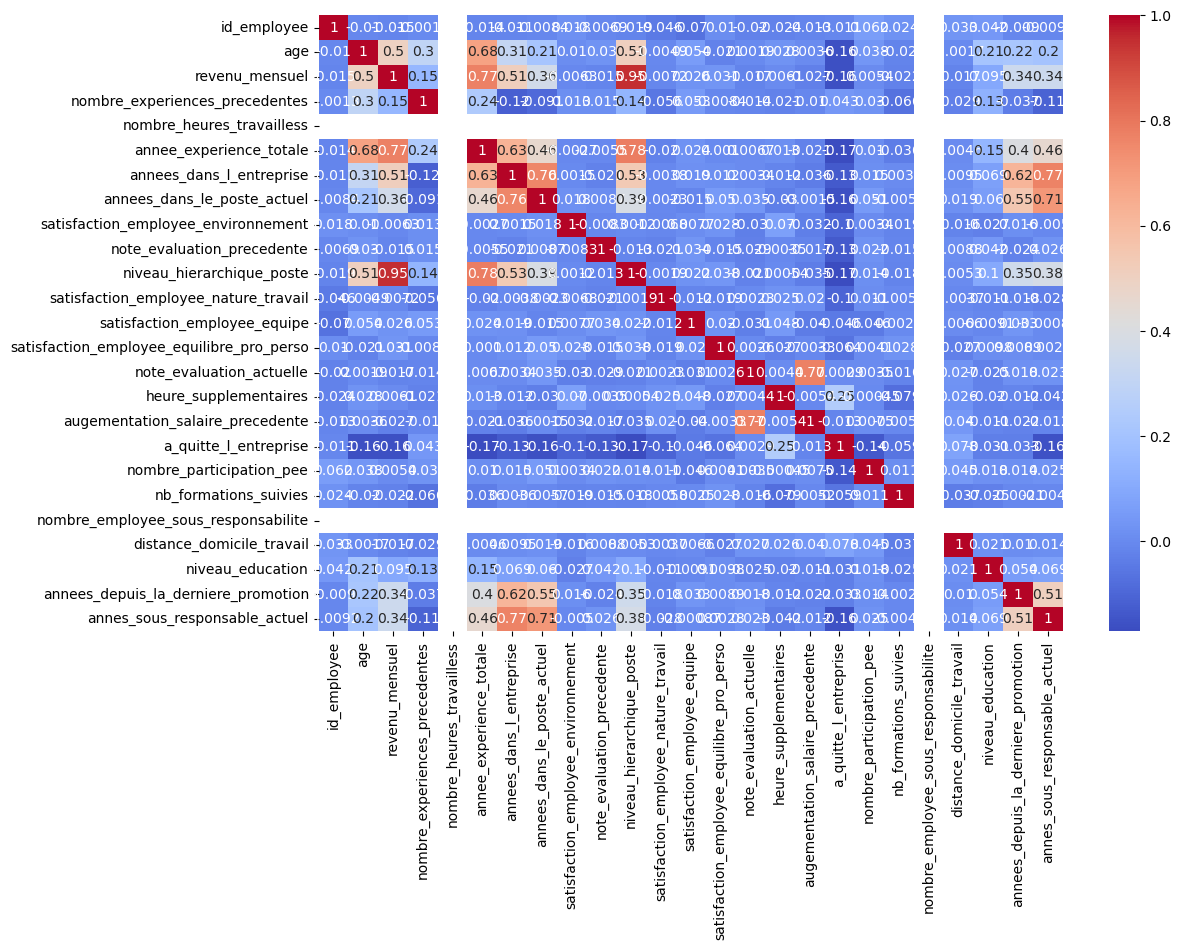

In [280]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.show()

<Axes: >

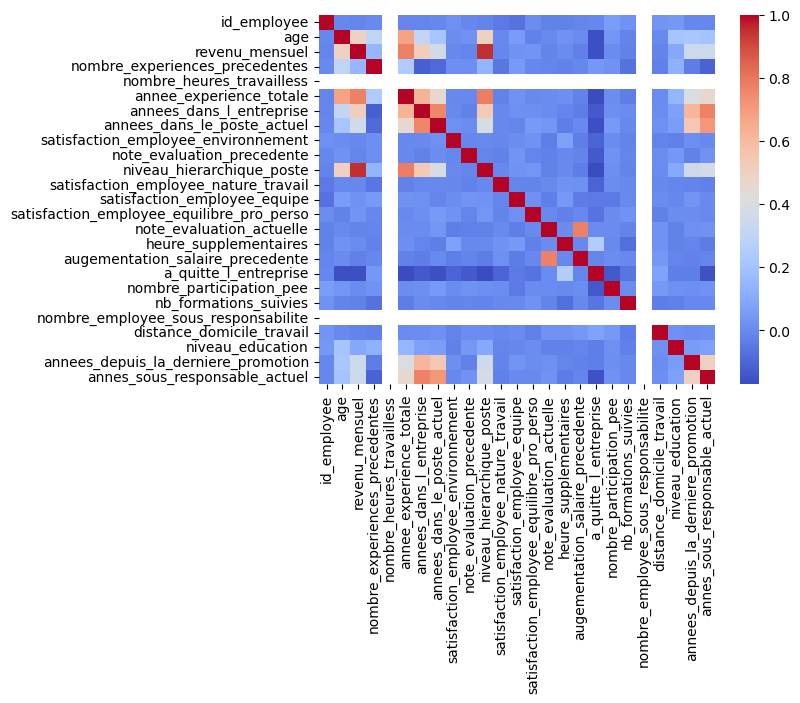

In [281]:
sns.heatmap(corr_pearson, cmap="coolwarm")

### Suppressions colonnes

In [282]:
data = df.copy()

In [283]:
data.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

In [284]:
data = data.drop(['id_employee'], axis = 1)

In [285]:
data = data.drop(['niveau_hierarchique_poste'], axis = 1)

In [286]:
data.columns.nunique()

30

In [287]:
number = data.select_dtypes(include=['int64','float64'])

In [288]:
corr = number.corr()

In [289]:
corr

,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,...,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
age,1.000000,0.497855,0.299635,NaN,0.680381,0.311309,0.212901,0.010146,0.029820,-0.004892,...,0.028062,0.003634,-0.159205,0.037510,-0.019621,NaN,-0.001686,0.208034,0.216513,0.202089
revenu_mensuel,0.497855,1.000000,0.149515,NaN,0.772893,0.514285,0.363818,-0.006259,-0.015271,-0.007157,...,0.006089,-0.027269,-0.159840,0.005408,-0.021736,NaN,-0.017014,0.094961,0.344978,0.344079
nombre_experiences_precedentes,0.299635,0.149515,1.000000,NaN,0.237639,-0.118421,-0.090754,0.012594,0.015012,-0.055699,...,-0.020786,-0.010238,0.043494,0.030075,-0.066054,NaN,-0.029251,0.126317,-0.036814,-0.110319
nombre_heures_travailless,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee_experience_totale,0.680381,0.772893,0.237639,NaN,1.000000,0.628133,0.460365,-0.002693,-0.005533,-0.020185,...,0.012754,-0.020608,-0.171063,0.010136,-0.035662,NaN,0.004628,0.148280,0.404858,0.459188
annees_dans_l_entreprise,0.311309,0.514285,-0.118421,NaN,0.628133,1.000000,0.758754,0.001458,-0.021355,-0.003803,...,-0.011687,-0.035991,-0.134392,0.015058,0.003569,NaN,0.009508,0.069114,0.618409,0.769212
annees_dans_le_poste_actuel,0.212901,0.363818,-0.090754,NaN,0.460365,0.758754,1.000000,0.018007,0.008717,-0.002305,...,-0.029758,-0.001520,-0.160545,0.050818,-0.005738,NaN,0.018845,0.060236,0.548056,0.714365
satisfaction_employee_environnement,0.010146,-0.006259,0.012594,NaN,-0.002693,0.001458,0.018007,1.000000,-0.008278,-0.006784,...,0.070132,-0.031701,-0.103369,0.003432,-0.019359,NaN,-0.016075,-0.027128,0.016194,-0.004999
note_evaluation_precedente,0.029820,-0.015271,0.015012,NaN,-0.005533,-0.021355,0.008717,-0.008278,1.000000,-0.021476,...,-0.003507,-0.017205,-0.130016,0.021523,-0.015338,NaN,0.008783,0.042438,-0.024184,0.025976
satisfaction_employee_nature_travail,-0.004892,-0.007157,-0.055699,NaN,-0.020185,-0.003803,-0.002305,-0.006784,-0.021476,1.000000,...,0.024539,0.020002,-0.103481,0.010690,-0.005779,NaN,-0.003669,-0.011296,-0.018214,-0.027656


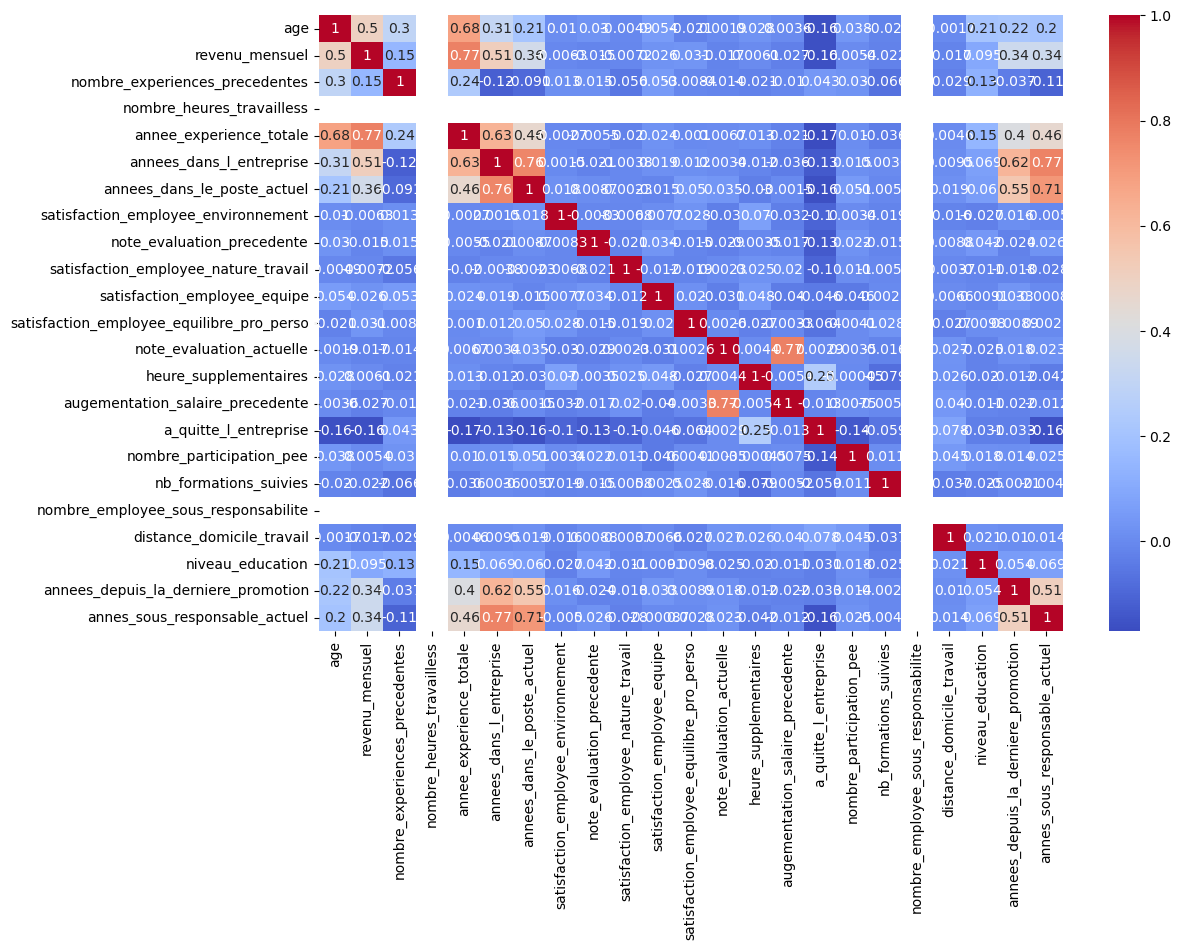

In [290]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [291]:
data = data.drop(['note_evaluation_actuelle','augementation_salaire_precedente'], axis = 1)

In [292]:
data.columns.nunique()

28

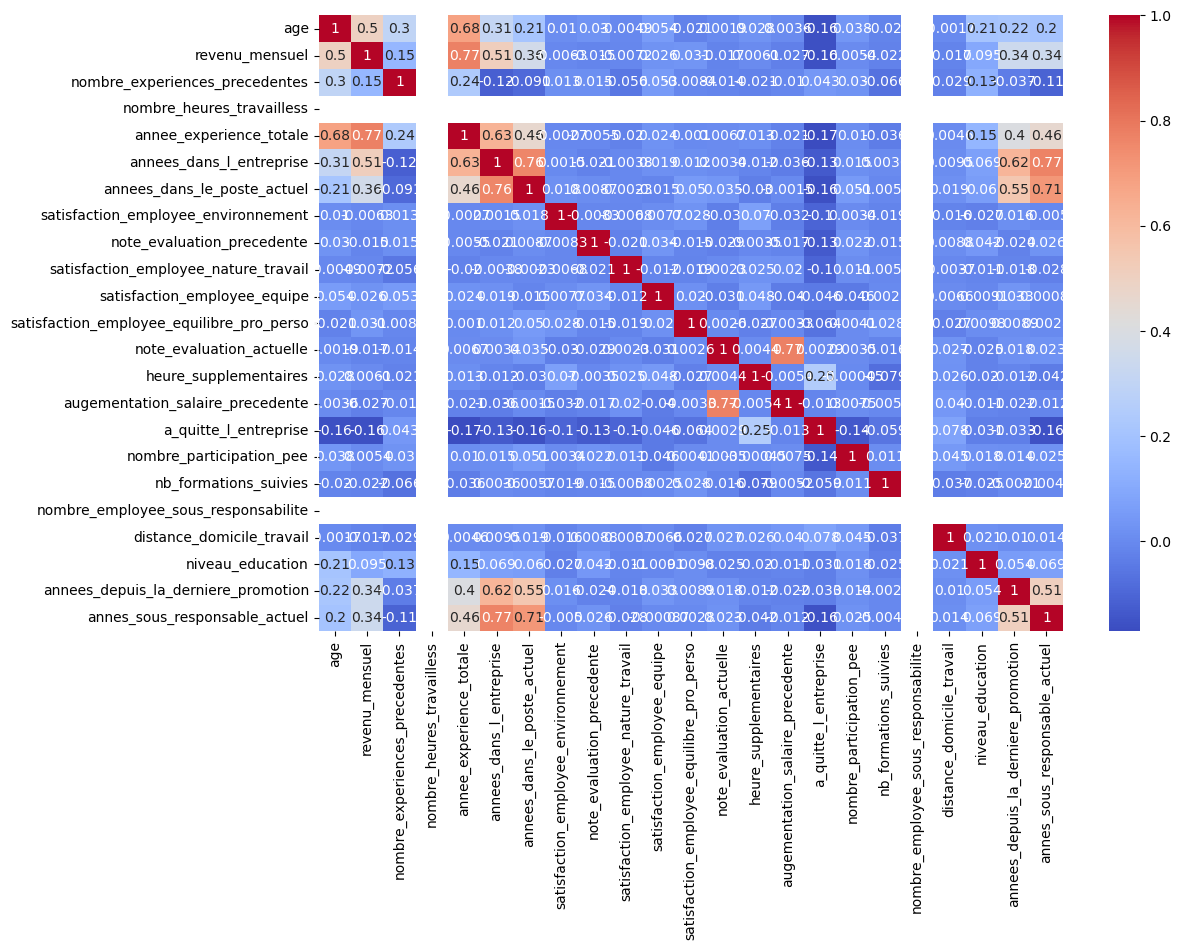

In [293]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [294]:
number = data.select_dtypes(include=['int64','float64'])

In [295]:
corr = number.corr()

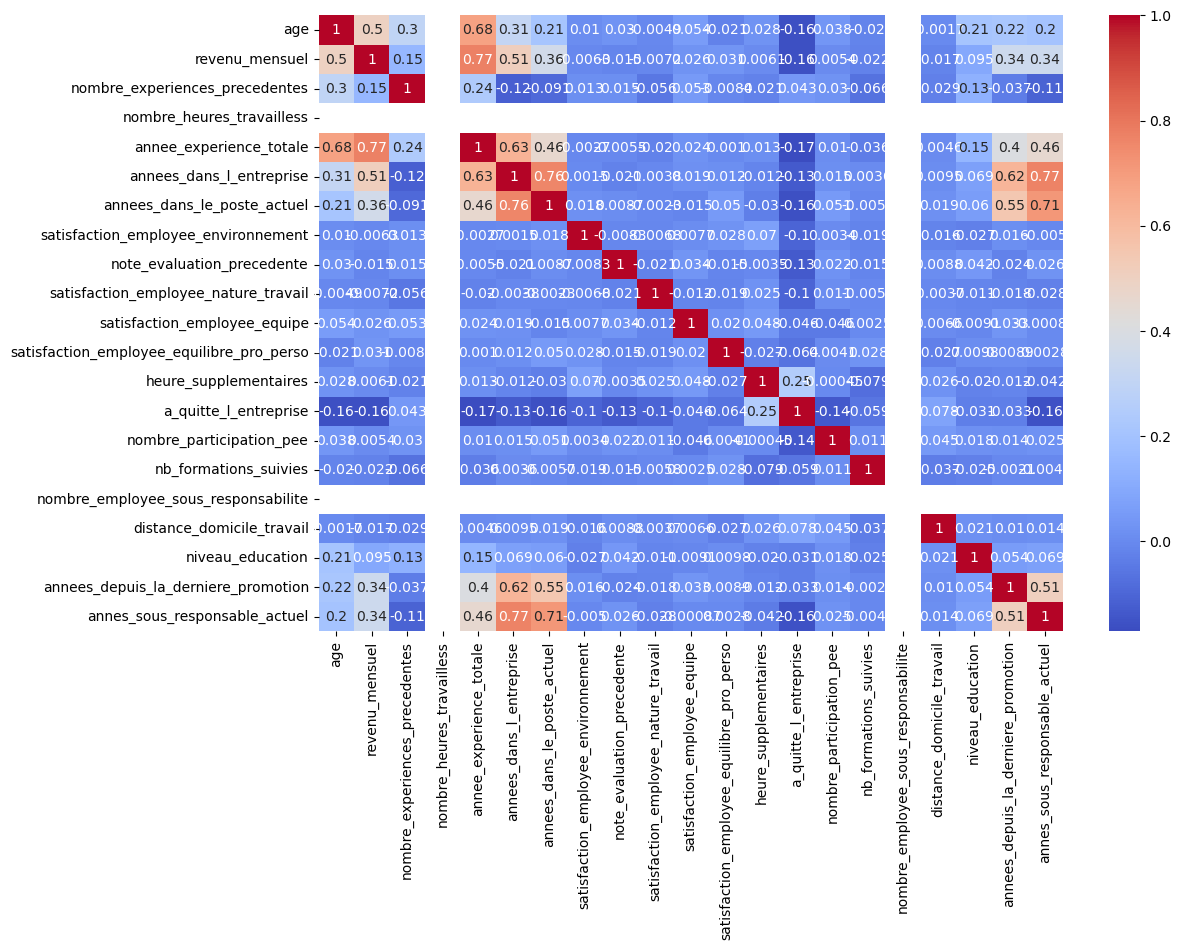

In [296]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [297]:
data = data.drop(['annees_dans_le_poste_actuel','annees_dans_l_entreprise'], axis = 1)

In [298]:
number = data.select_dtypes(include=['int64','float64'])

In [299]:
corrs = number.corr(method='pearson')

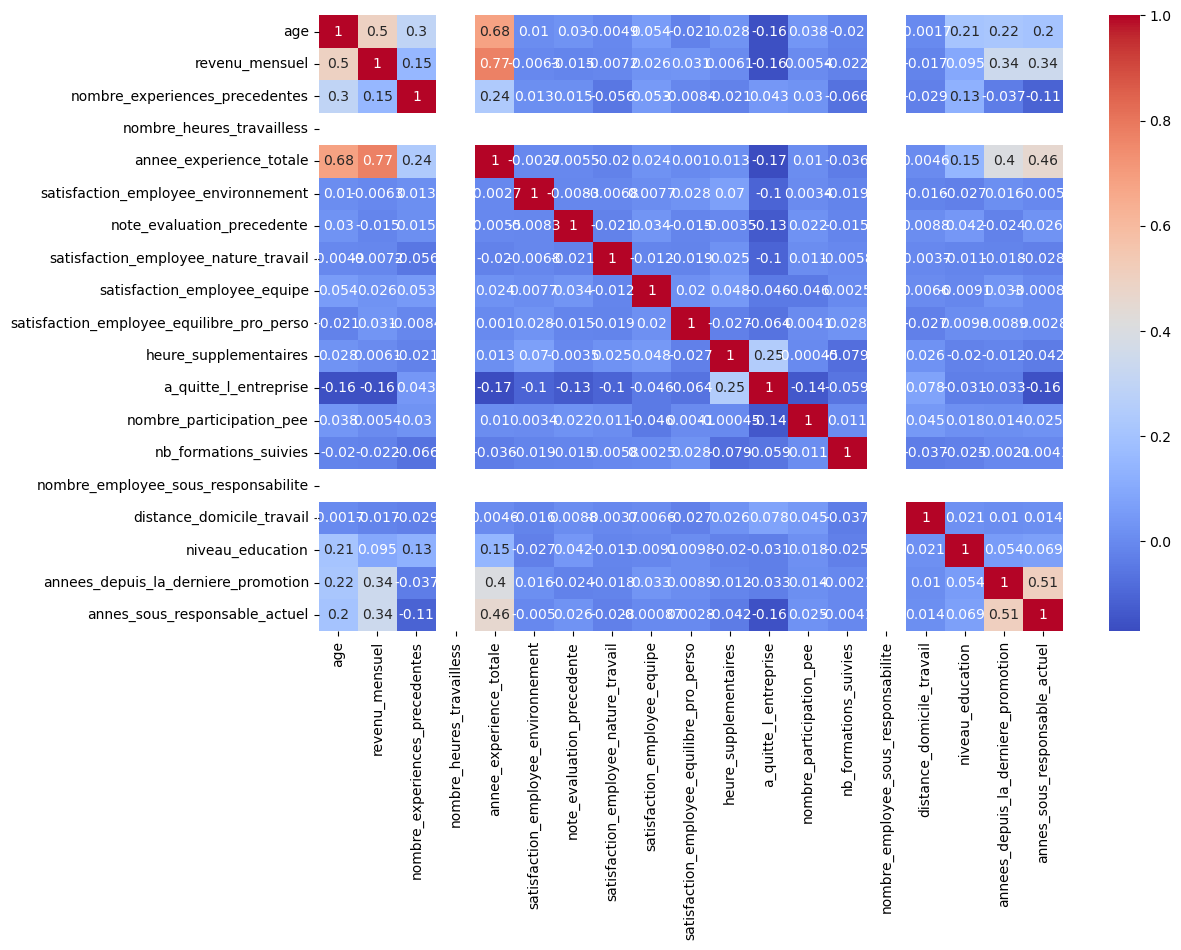

In [300]:
plt.figure(figsize=(12,8))
sns.heatmap(corrs, annot=True, cmap="coolwarm")
plt.show()

* Tracer un pairplot pour mesurer l’intensité des corrélations non-linéaires s’il y en a. Vous pouvez également compléter le pairplot avec une matrice de corrélation de Spearman.

In [301]:
number.columns

Index(['age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'heure_supplementaires',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

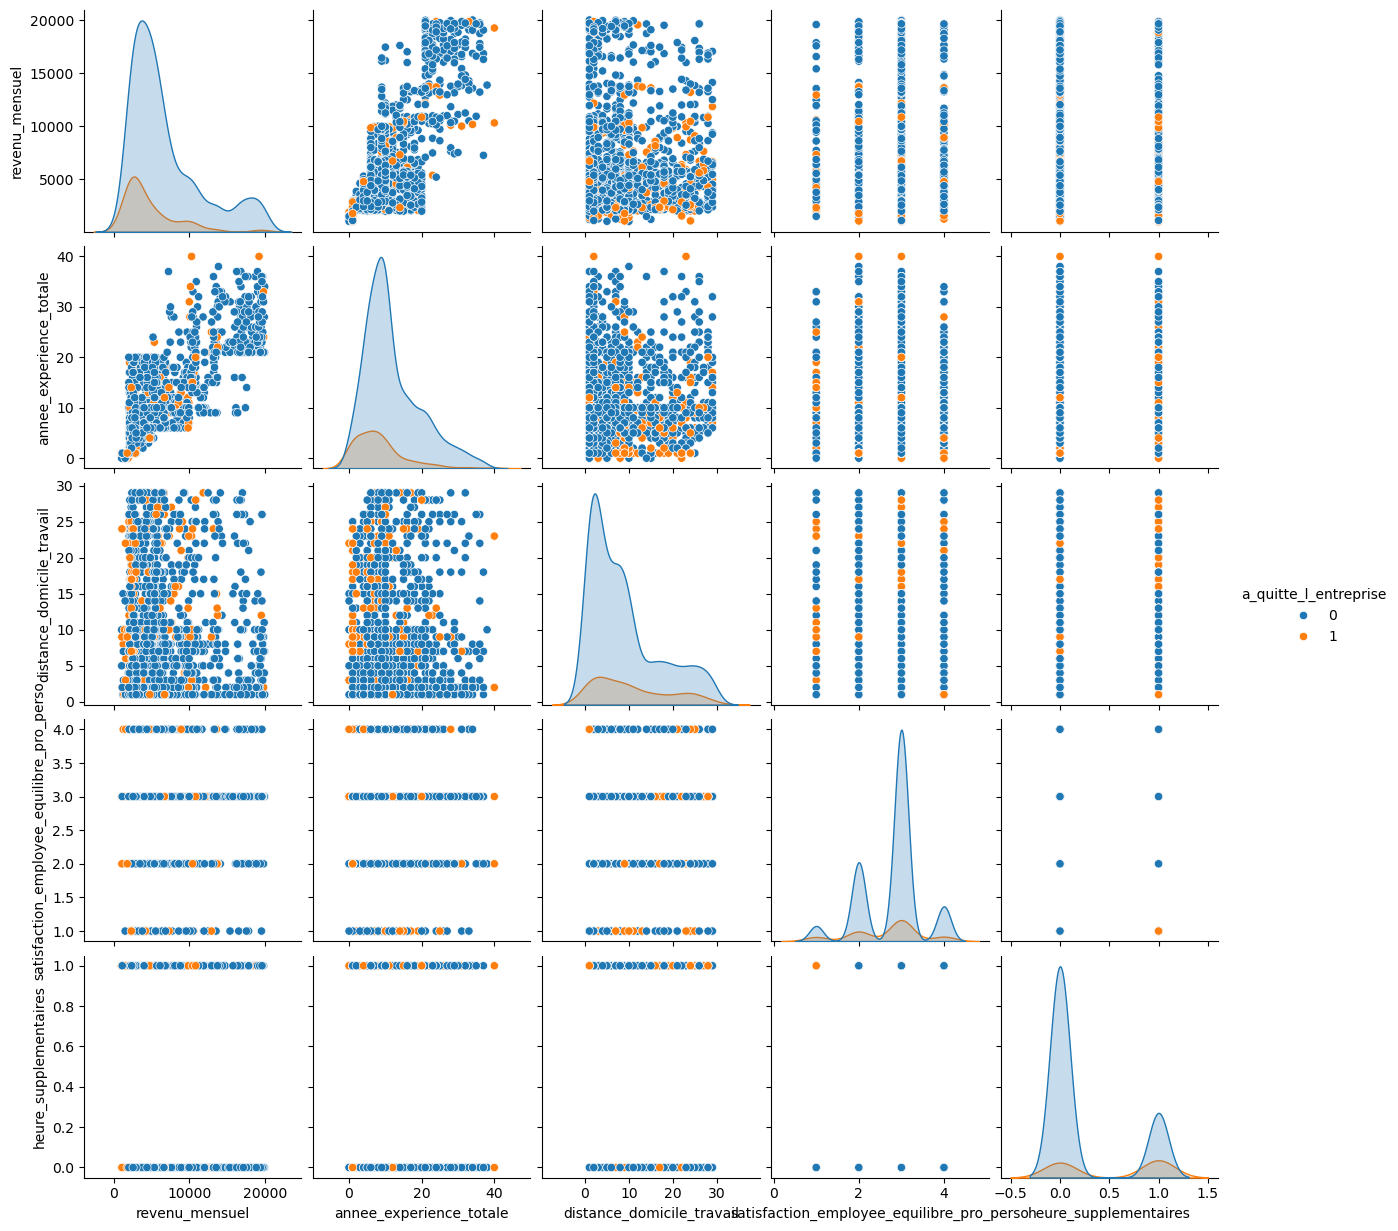

In [302]:
columns = [
    "revenu_mensuel",
    "annee_experience_totale",
    "distance_domicile_travail",
    "satisfaction_employee_equilibre_pro_perso",
    "heure_supplementaires",
    "a_quitte_l_entreprise"
]

sns.pairplot(data[columns], hue="a_quitte_l_entreprise")

In [303]:
entier = data.select_dtypes(include = ['int64','float64'])
corr_spearmans = entier.corr(method="spearman")

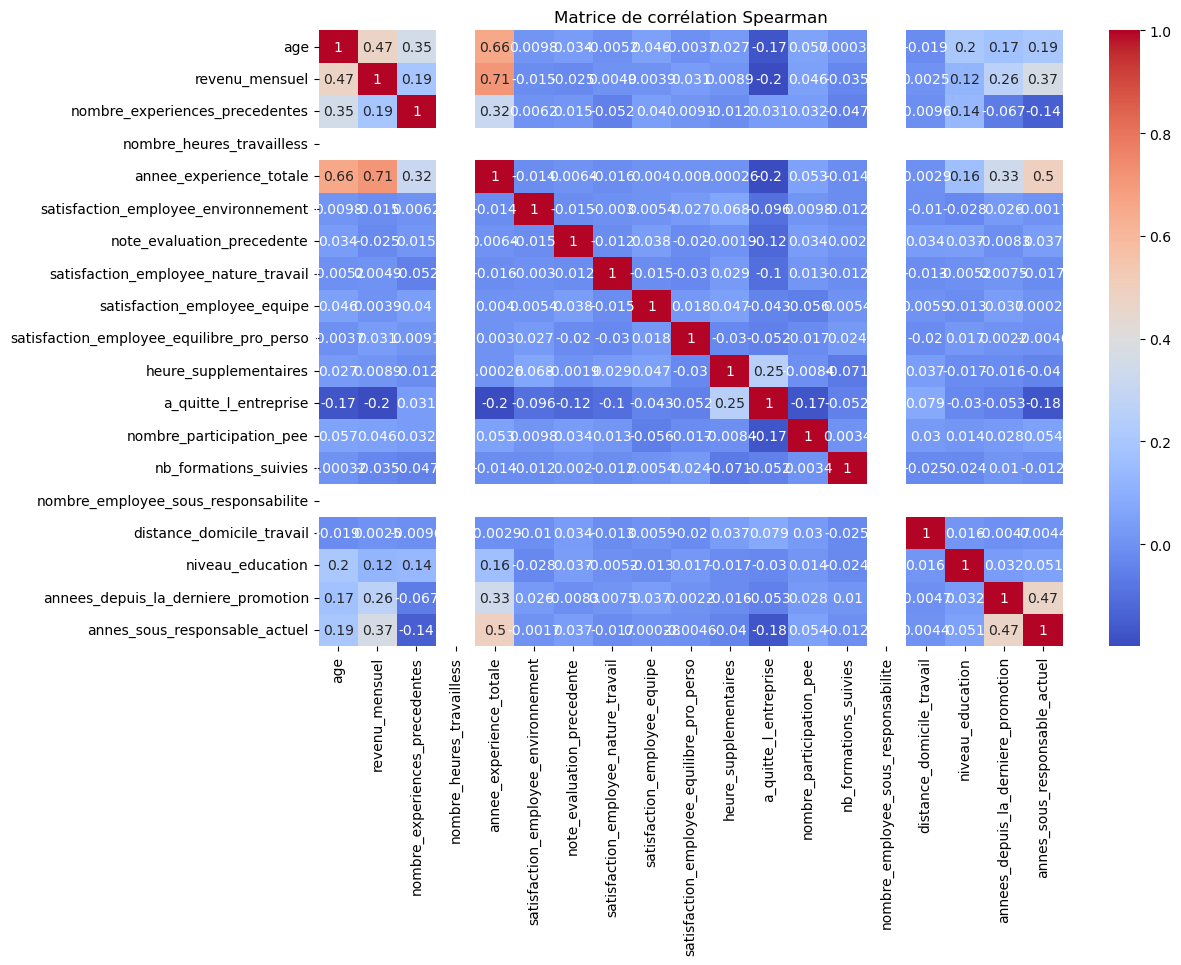

In [304]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_spearmans, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation Spearman")
plt.show()

* Sélectionner une méthode d’encoding adaptée pour les features qualitatives en fonction de leur sens métier.

In [305]:
cat.columns

Index(['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement'],
      dtype='object')

In [306]:
data['genre'].value_counts()

genre
m    882
f    588
Name: count, dtype: int64

In [307]:
data['statut_marital'].value_counts()

statut_marital
marié(e)       673
célibataire    470
divorcé(e)     327
Name: count, dtype: int64

In [308]:
data['departement'].value_counts()

departement
consulting             961
commercial             446
ressources humaines     63
Name: count, dtype: int64

In [309]:
data['poste'].value_counts()

poste
cadre commercial           326
assistant de direction     292
consultant                 259
tech lead                  145
manager                    131
senior manager             102
représentant commercial     83
directeur technique         80
ressources humaines         52
Name: count, dtype: int64

In [310]:
data['domaine_etude'].value_counts()

domaine_etude
infra & cloud              606
transformation digitale    464
marketing                  159
entrepreunariat            132
autre                       82
ressources humaines         27
Name: count, dtype: int64

In [311]:
data['ayant_enfants'].value_counts()

ayant_enfants
y    1470
Name: count, dtype: int64

In [312]:
data['frequence_deplacement'].value_counts()

frequence_deplacement
occasionnel    1043
frequent        277
aucun           150
Name: count, dtype: int64

* Nous constatons dans notre cas que nos colonnes n'ont pas d'ordre donc nous allons appliquer le one hot encoding

In [313]:
#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [314]:
qualitatives = data.select_dtypes(include=["object", "category"]).columns.tolist()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

ohe.fit(data[qualitatives])

encoder_transforming = ohe.transform(data[qualitatives])

df_ohe = pd.DataFrame(
    data=encoder_transforming,
    columns=ohe.get_feature_names_out(qualitatives),
    index=data.index
)
df_ohe.describe()

,genre_f,genre_m,statut_marital_célibataire,statut_marital_divorcé(e),statut_marital_marié(e),departement_commercial,departement_consulting,departement_ressources humaines,poste_assistant de direction,poste_cadre commercial,...,domaine_etude_autre,domaine_etude_entrepreunariat,domaine_etude_infra & cloud,domaine_etude_marketing,domaine_etude_ressources humaines,domaine_etude_transformation digitale,ayant_enfants_y,frequence_deplacement_aucun,frequence_deplacement_frequent,frequence_deplacement_occasionnel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,0.400000,0.600000,0.319728,0.222449,0.457823,0.303401,0.653741,0.042857,0.198639,0.221769,...,0.055782,0.089796,0.412245,0.108163,0.018367,0.315646,1.0,0.102041,0.188435,0.709524
std,0.490065,0.490065,0.466530,0.416033,0.498387,0.459884,0.475939,0.202604,0.399112,0.415578,...,0.229579,0.285986,0.492406,0.310692,0.134321,0.464931,0.0,0.302805,0.391193,0.454137
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.0,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000


* Concatenation des deux catégories

In [315]:
quantitatives = data.select_dtypes(include=['int64','float64'])
Final_data =pd.concat([quantitatives, df_ohe], axis=1)


In [316]:
Final_data

,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,...,domaine_etude_autre,domaine_etude_entrepreunariat,domaine_etude_infra & cloud,domaine_etude_marketing,domaine_etude_ressources humaines,domaine_etude_transformation digitale,ayant_enfants_y,frequence_deplacement_aucun,frequence_deplacement_frequent,frequence_deplacement_occasionnel
0,41,5993,8,80,8,2,3,4,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,5130,1,80,10,3,2,2,4,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,37,2090,6,80,7,4,2,3,2,3,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,33,2909,1,80,8,4,3,3,3,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,27,3468,9,80,6,1,3,2,4,3,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,2571,4,80,17,3,4,4,3,3,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1466,39,9991,4,80,9,4,2,1,1,3,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1467,27,6142,1,80,6,2,4,2,2,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1468,49,5390,2,80,17,4,2,2,4,2,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [317]:
Final_data.isnull().sum()

age                                          0
revenu_mensuel                               0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
satisfaction_employee_environnement          0
note_evaluation_precedente                   0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
heure_supplementaires                        0
a_quitte_l_entreprise                        0
nombre_participation_pee                     0
nb_formations_suivies                        0
nombre_employee_sous_responsabilite          0
distance_domicile_travail                    0
niveau_education                             0
annees_depuis_la_derniere_promotion          0
annes_sous_responsable_actuel                0
genre_f                                      0
genre_m                                      0
statut_marita

### Modélisation du premier modèle de classification

In [318]:
Final_data['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64

In [319]:
pred = Final_data.copy()

In [320]:
X = pred.drop(['a_quitte_l_entreprise'], axis = 1)

In [321]:
y = pred['a_quitte_l_entreprise']

In [322]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: a_quitte_l_entreprise, Length: 1470, dtype: int64

In [323]:
from sklearn.preprocessing import StandardScaler

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [325]:
scaler = StandardScaler()

In [326]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### Entraînement du modèle Dummy

In [327]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_train_pred_dummy = dummy.predict(X_train)
y_test_pred_dummy = dummy.predict(X_test)

### Entraînement modèle Linéaire nous allons choisir la logistique regression

In [328]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train, y_train)

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [329]:
# Scaling
scalers = StandardScaler()
scaled_train = scalers.fit_transform(X_train)
scaled_test = scalers.transform(X_test)

In [330]:
# Prediction
y_train_pred_log = log_model.predict(X_train)
y_test_pred_log = log_model.predict(X_test)

### Entraînement du modèle non linéaire et nous allons Random Forest

In [331]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [332]:
## Scaling
scaler = StandardScaler()
scaled_X_tr = scaler.fit_transform(X_train)
scaled_X_te = scaler.transform(X_test)

In [333]:
# Prédictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

* A minima, vous devez calculer les métriques d’évaluation incontournables en classification : matrice de confusion, rappel et précision. Le classification_report() de sklearn peut vous aider.

In [334]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, model_name):
    print(f"===== {model_name} =====")

    print("\n--- TRAIN ---")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

    print("\n--- TEST ---")
    print(confusion_matrix(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred))

In [335]:
evaluate_model(y_train, y_train_pred_dummy, y_test, y_test_pred_dummy, "Dummy")

evaluate_model(y_train, y_train_pred_log, y_test, y_test_pred_log, "Logistic Regression")

evaluate_model(y_train, y_train_pred_rf, y_test, y_test_pred_rf, "Random Forest")

===== Dummy =====

--- TRAIN ---
[[986   0]
 [190   0]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       986
           1       0.00      0.00      0.00       190

    accuracy                           0.84      1176
   macro avg       0.42      0.50      0.46      1176
weighted avg       0.70      0.84      0.76      1176


--- TEST ---
[[247   0]
 [ 47   0]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294

===== Logistic Regression =====

--- TRAIN ---
[[968  18]
 [100  90]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       986
           1       0.83      0.47      0.60       190

    accuracy       

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

### Affichons la matrice de confusion pour log_model

In [336]:
from sklearn.metrics import ConfusionMatrixDisplay

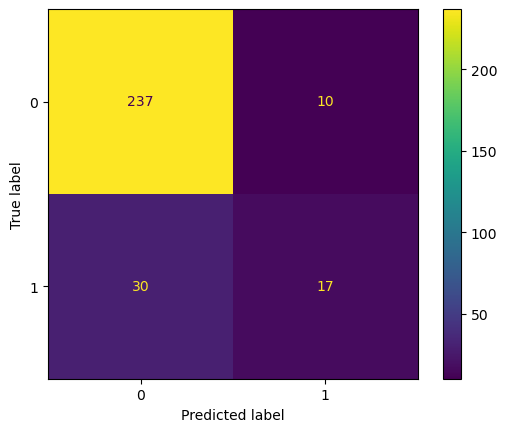

In [337]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_log)

### Conclusion des observations

In [338]:
from sklearn.metrics import accuracy_score

In [339]:
accuracy_score(y_test, y_test_pred_log)

0.8639455782312925

### Affichons de manière simple pour chaque modèle de train et de test

In [340]:
evaluate_model(y_train, y_train_pred_dummy, y_test, y_test_pred_dummy, "Dummy")

===== Dummy =====

--- TRAIN ---
[[986   0]
 [190   0]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       986
           1       0.00      0.00      0.00       190

    accuracy                           0.84      1176
   macro avg       0.42      0.50      0.46      1176
weighted avg       0.70      0.84      0.76      1176


--- TEST ---
[[247   0]
 [ 47   0]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294



c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

* Le modèle ne detecte aucun départ
* Le modèle Dummy montre que le dataset est déséquilibré. L’accuracy élevée est trompeuse car le modèle ne détecte aucun employé quittant l’entreprise.

### Logistique Regression

In [341]:
evaluate_model(y_train, y_train_pred_log, y_test, y_test_pred_log, "Logistic Regression")

===== Logistic Regression =====

--- TRAIN ---
[[968  18]
 [100  90]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       986
           1       0.83      0.47      0.60       190

    accuracy                           0.90      1176
   macro avg       0.87      0.73      0.77      1176
weighted avg       0.89      0.90      0.89      1176


--- TEST ---
[[237  10]
 [ 30  17]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       247
           1       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



* Train
    * Avec une accuracy de 0.90 et un recal de classe 1 0.47
* Test
    * Avec une accuracy de 0.87 et un recal de classe 1 0.36
* Nous constatons que le modèle apprend reellement à travers les données et une amélioration par rapport au dummy
* train ~ test
* Pas d'overfiting
* Inconvénient : Le modèle rate trop d'employé qui quitte l'entreprise

### Random Forest

In [342]:
evaluate_model(y_train, y_train_pred_rf, y_test, y_test_pred_rf, "Random Forest")

===== Random Forest =====

--- TRAIN ---
[[986   0]
 [  0 190]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


--- TEST ---
[[242   5]
 [ 43   4]]
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



* Train
    * Avec une accuracy de 1 et un recall de classe 1 = 1
* Test
    * Avec une accuracy de 0.84 et un recall de classe 1 = 0.11
* Nous constatons que le  train = 100% et que la partie test est beaucoup plus faible
* Le modèle Random Forest présente un fort surapprentissage, avec des performances parfaites sur le jeu d’entraînement mais une forte dégradation sur le jeu de test. De plus, il est peu efficace pour détecter les employés quittant l’entreprise, ce qui le rend peu adapté en l’état.

### Partie 4 : Amélioration de l'approche de classification

* Avant toute implémentation en code, mettre sur le papier votre approche de modélisation. C’est-à-dire : avec quelle méthodologie je découpe mon jeu de données en apprentissage et test, de quelles métriques d’évaluation je vais avoir besoin etc.

* L'objectif de ce projet est de determiner si un employé va quitte_l_entreprise à travers ces caractéristiques c'est à dire les features présentes
* Pour la separation du jeu de donnée nous avons 2 elements essentiels :
    * X qui representent les features
    * y la target ou cible
    * Nous avons choisi 80 % d'entraînement contre 20 % de test
    * Nous avons utiliser la stratification pour garder les mêmes proportions de train et de test

* Pendant votre validation croisée, stocker les métriques de chaque itération de Fold dans une liste. Il est très utile de calculer une moyenne ainsi qu’un écart-type sur ces listes. Cela vous donnera une bonne indication sur l’existence ou non d’un overfit, ainsi que la capacité d’un modèle à généraliser son apprentissage à de nouvelles données.

In [343]:
log_model_balanced = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

log_model_balanced.fit(X_train, y_train)

#Scaling

scal = StandardScaler()
scal_train = scal.fit_transform(X_train)
scal_test = scal.transform(X_test)

y_train_pred_log_bal = log_model_balanced.predict(X_train)
y_test_pred_log_bal = log_model_balanced.predict(X_test)

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [344]:
rf_model_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model_balanced.fit(X_train, y_train)

# scaling
scale = StandardScaler()
scale_train = scale.fit_transform(X_train)
scale_test = scale.transform(X_test)

y_train_pred_rf_bal = rf_model_balanced.predict(X_train)
y_test_pred_rf_bal = rf_model_balanced.predict(X_test)

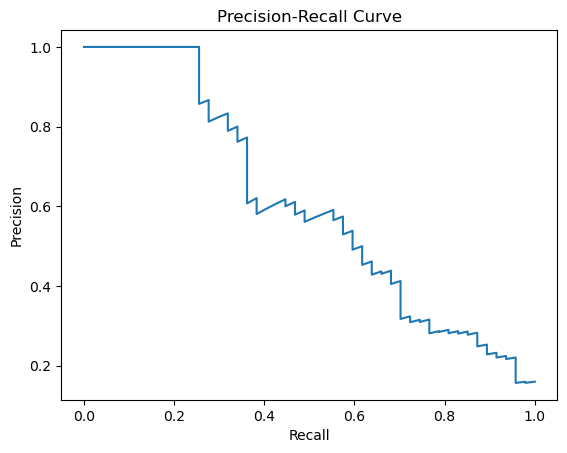

In [345]:
from sklearn.metrics import precision_recall_curve

y_scores = log_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [346]:
y_pred_custom = (y_scores >= 0.3).astype(int)

In [347]:
y_pred_custom

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0])

In [348]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
import numpy as np


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recall_scores = []

for train_index, val_index in kf.split(X, y):
    X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
    y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

    model = LogisticRegression(max_iter=3000, class_weight="balanced")
    model.fit(X_tr, y_tr)
    scale = StandardScaler()
    scale_x = scale.fit_transform(X_train)
    scale_X = scale.transform(X_test)

    y_val_pred = model.predict(X_val)

    recall = recall_score(y_val, y_val_pred)
    recall_scores.append(recall)

print("Recall moyen :", np.mean(recall_scores))
print("Ecart-type :", np.std(recall_scores))

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

Recall moyen : 0.725531914893617
Ecart-type : 0.02530931330504324


c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [349]:
recall_scores

[0.75, 0.75, 0.723404255319149, 0.723404255319149, 0.6808510638297872]

In [350]:
recall

0.6808510638297872

In [351]:
from sklearn.metrics import PrecisionRecallDisplay ,RocCurveDisplay

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


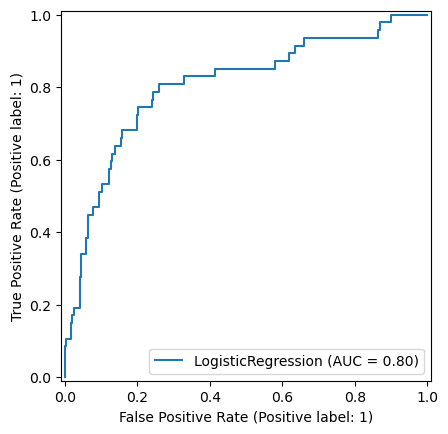

In [352]:
RocCurveDisplay.from_estimator(model, scale_X, y_test)

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


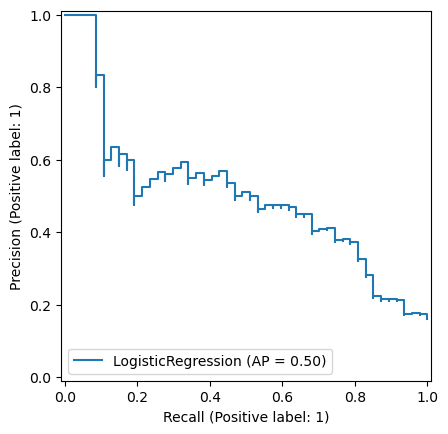

In [353]:
PrecisionRecallDisplay.from_estimator(model,scale_X, y_test)

In [354]:
model.predict_proba(X_test)[0]

array([0.88256842, 0.11743158])

### Pipelines

In [355]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# colonnes
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# pipeline complet
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# entraînement
pipeline.fit(X_train, y_train)

# prédictions
y_prediction = pipeline.predict(X_test)

### Features engineering

In [356]:
pred.columns

Index(['age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'heure_supplementaires',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'genre_f', 'genre_m', 'statut_marital_célibataire',
       'statut_marital_divorcé(e)', 'statut_marital_marié(e)',
       'departement_commercial', 'departement_consulting',
       'departement_ressources humaines', 'poste_assistant de direction',
       'poste_cadre commercial', 'poste_consultant',
       'poste_directeur technique', 'poste_manager',
       'post

In [357]:
pred["charge_travail"] = pred["nombre_heures_travailless"] + pred["heure_supplementaires"]

In [358]:
pred["stress_transport"] = pred["distance_domicile_travail"] * pred["frequence_deplacement_frequent"]

* Dans notre partie de feature engineering nous nous sommes concentrés sur 2 aspects :
    * Le stress lié au travail
    * Charge de travail réelle

In [359]:
pred.columns

Index(['age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'heure_supplementaires',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'genre_f', 'genre_m', 'statut_marital_célibataire',
       'statut_marital_divorcé(e)', 'statut_marital_marié(e)',
       'departement_commercial', 'departement_consulting',
       'departement_ressources humaines', 'poste_assistant de direction',
       'poste_cadre commercial', 'poste_consultant',
       'poste_directeur technique', 'poste_manager',
       'post

### Utilisations des modèles non linéaires

In [360]:
X = pred.drop(['a_quitte_l_entreprise'], axis = 1)
y = pred['a_quitte_l_entreprise']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [361]:
rf_model_balanceds = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model_balanceds.fit(X_train, y_train)

# scaling
scales = StandardScaler()
scale_train = scales.fit_transform(X_train)
scale_test = scales.transform(X_test)

y_trains_pred = rf_model_balanceds.predict(X_train)
y_tests_pred = rf_model_balanceds.predict(X_test)

### Métriques

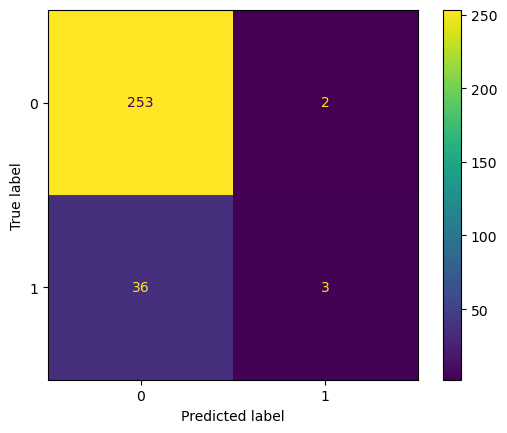

In [362]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_tests_pred)

### Classification report

In [363]:
print(classification_report(y_test, y_tests_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.60      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.74      0.53      0.53       294
weighted avg       0.84      0.87      0.82       294



### ROC

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


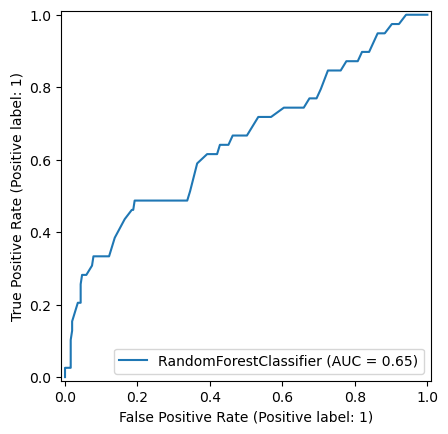

In [364]:
RocCurveDisplay.from_estimator(rf_model_balanceds, scale_test,y_test)

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


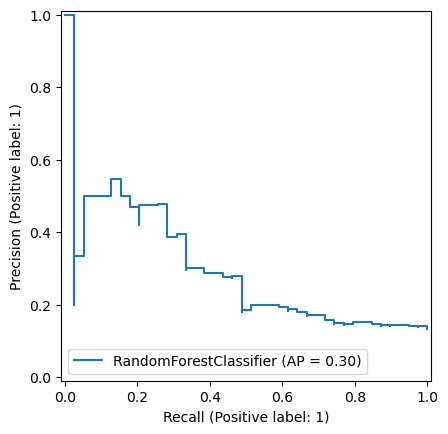

In [365]:
PrecisionRecallDisplay.from_estimator(rf_model_balanceds, scale_test,y_test)

In [366]:
from sklearn.metrics import fbeta_score

In [367]:
fbeta_score(y_test, y_tests_pred, beta=2)

0.09316770186335403

### Interpretations des nouvelles performances

* Nous constatons une large amélioration au niveau de notre modèle non linéaire

### Optimisations et interpretations comportements modèles

### Importance Globale

In [368]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_model_balanceds,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="recall",
    n_jobs=-1)


In [369]:
importances = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(importances.head(10))


nombre_participation_pee               0.028205
statut_marital_célibataire             0.020513
statut_marital_marié(e)                0.017949
domaine_etude_infra & cloud            0.015385
satisfaction_employee_environnement    0.012821
annee_experience_totale                0.010256
poste_tech lead                        0.007692
poste_manager                          0.005128
heure_supplementaires                  0.002564
age                                    0.002564
dtype: float64


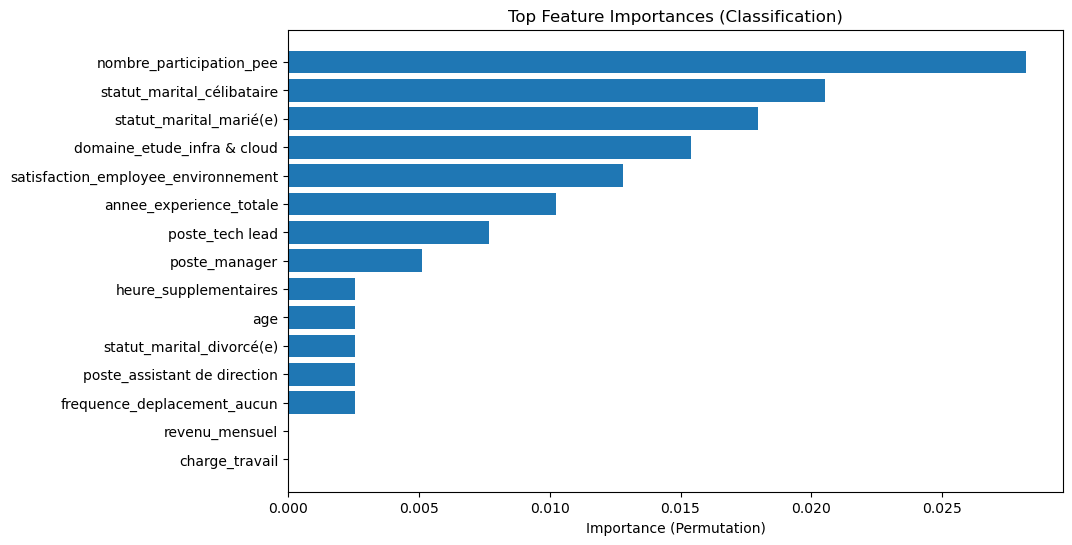

In [370]:
top_n = 15
top_features = importances.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel("Importance (Permutation)")
plt.title("Top Feature Importances (Classification)")
plt.show()

In [371]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X_test.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

satisfaction_employee_environnement          0.026871
annees_depuis_la_derniere_promotion          0.025510
heure_supplementaires                        0.025170
satisfaction_employee_equipe                 0.024490
revenu_mensuel                               0.023469
annee_experience_totale                      0.019388
poste_consultant                             0.017687
note_evaluation_precedente                   0.017687
annes_sous_responsable_actuel                0.016667
departement_ressources humaines              0.016327
age                                          0.015646
satisfaction_employee_equilibre_pro_perso    0.009864
nombre_participation_pee                     0.009184
domaine_etude_entrepreunariat                0.008844
poste_ressources humaines                    0.008163
dtype: float64


### Utilisations de shap cas du randomforest

In [372]:
import shap

ModuleNotFoundError: No module named 'shap'

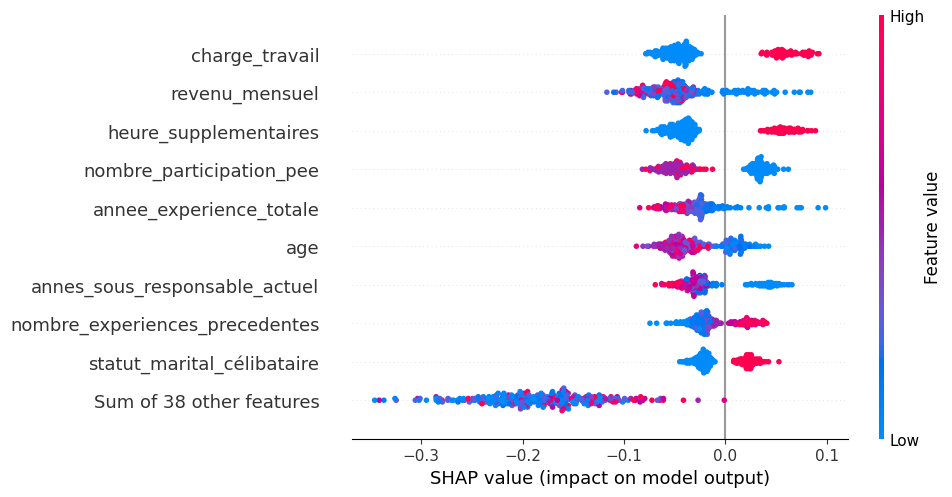

In [ ]:
explainer = shap.Explainer(rf_model_balanceds)
shap_values = explainer(X_test)

# Select the SHAP values for the positive class (class 1)
shap.plots.beeswarm(shap_values[:, :, 1])

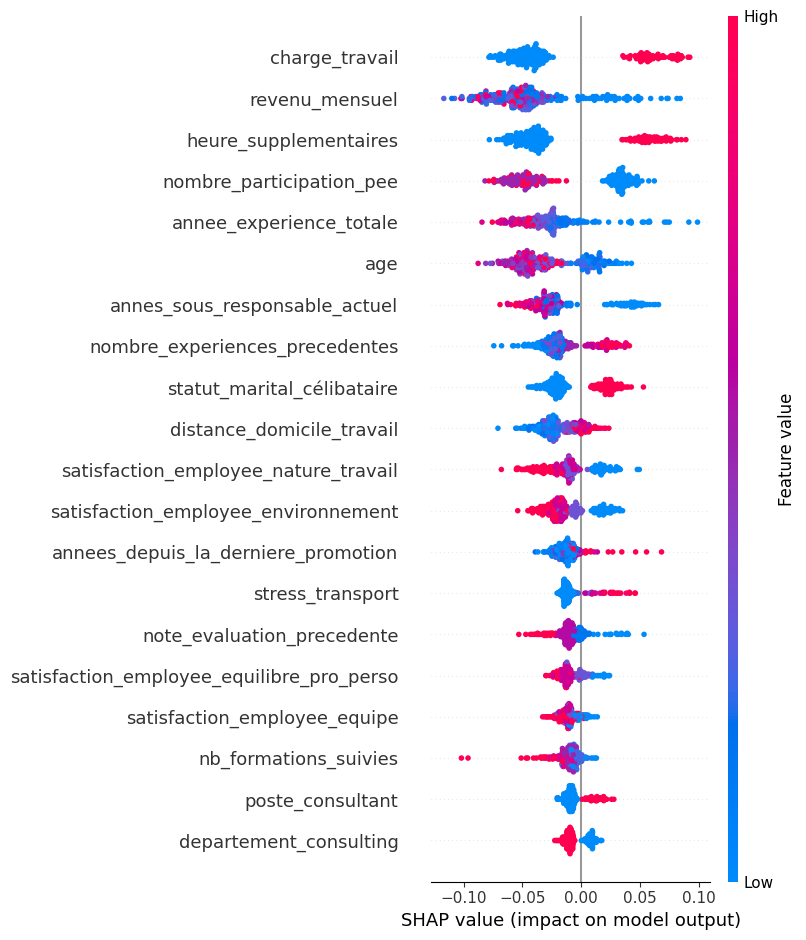

In [ ]:
explainer = shap.TreeExplainer(rf_model_balanceds)
shap_values = explainer.shap_values(X_test)

# Correctly select SHAP values for the positive class (index 1) across all samples and features
shap.summary_plot(shap_values[:, :, 1], X_test)

### Faisons à nouveau un entraînement du modèle avec logistique regression comme modèle

In [ ]:
pred.columns.nunique()

48

In [374]:
X = pred[["charge_travail","revenu_mensuel","heure_supplementaires","nombre_participation_pee","annee_experience_totale","age","annes_sous_responsable_actuel","nombre_experiences_precedentes","statut_marital_célibataire","distance_domicile_travail"]]
y = pred['a_quitte_l_entreprise']
feature = X.columns.tolist()
feature

['charge_travail',
 'revenu_mensuel',
 'heure_supplementaires',
 'nombre_participation_pee',
 'annee_experience_totale',
 'age',
 'annes_sous_responsable_actuel',
 'nombre_experiences_precedentes',
 'statut_marital_célibataire',
 'distance_domicile_travail']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
scale = StandardScaler()
scale_X_Train = scale.fit_transform(X_train)
scale_X_Test = scale.transform(X_test)

In [ ]:
nlr = LogisticRegression()
nlr.fit(X_train, y_train)

c:\Users\El. OURY BALDE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# Prediction
y_train_pred_nlr = nlr.predict(X_train)
y_test_pred_nlr = nlr.predict(X_test)

In [ ]:
# Evaluation
evaluate_model(y_train, y_train_pred_lr, y_test, y_test_pred_lr, "Logistic Regression")


===== Logistic Regression =====

--- TRAIN ---
[[716 262]
 [ 53 145]]
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       978
           1       0.36      0.73      0.48       198

    accuracy                           0.73      1176
   macro avg       0.64      0.73      0.65      1176
weighted avg       0.83      0.73      0.76      1176


--- TEST ---
[[178  77]
 [ 18  21]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79       255
           1       0.21      0.54      0.31        39

    accuracy                           0.68       294
   macro avg       0.56      0.62      0.55       294
weighted avg       0.82      0.68      0.73       294



In [ ]:
# Evaluation
evaluate_model(y_train, y_train_pred_nlr, y_test, y_test_pred_nlr, "Logistic Regression Non-Balanced")

===== Logistic Regression Non-Balanced =====

--- TRAIN ---
[[973   5]
 [192   6]]
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       978
           1       0.55      0.03      0.06       198

    accuracy                           0.83      1176
   macro avg       0.69      0.51      0.48      1176
weighted avg       0.79      0.83      0.76      1176


--- TEST ---
[[251   4]
 [ 39   0]]
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       255
           1       0.00      0.00      0.00        39

    accuracy                           0.85       294
   macro avg       0.43      0.49      0.46       294
weighted avg       0.75      0.85      0.80       294



In [375]:
## Stockage des features de X en liste pour la reutilisation dans l'api
feature

['charge_travail',
 'revenu_mensuel',
 'heure_supplementaires',
 'nombre_participation_pee',
 'annee_experience_totale',
 'age',
 'annes_sous_responsable_actuel',
 'nombre_experiences_precedentes',
 'statut_marital_célibataire',
 'distance_domicile_travail']

In [377]:
### Enregistrons le modèle
import joblib
joblib.dump(nlr, "logistic_model.pkl")

['logistic_model.pkl']

In [378]:
## Enregistrons les features    
joblib.dump(feature, "features.pkl")

['features.pkl']

In [385]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   charge_travail                  1470 non-null   int64  
 1   revenu_mensuel                  1470 non-null   int64  
 2   heure_supplementaires           1470 non-null   int64  
 3   nombre_participation_pee        1470 non-null   int64  
 4   annee_experience_totale         1470 non-null   int64  
 5   age                             1470 non-null   int64  
 6   annes_sous_responsable_actuel   1470 non-null   int64  
 7   nombre_experiences_precedentes  1470 non-null   int64  
 8   statut_marital_célibataire      1470 non-null   float64
 9   distance_domicile_travail       1470 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 115.0 KB


In [386]:
X

,charge_travail,revenu_mensuel,heure_supplementaires,nombre_participation_pee,annee_experience_totale,age,annes_sous_responsable_actuel,nombre_experiences_precedentes,statut_marital_célibataire,distance_domicile_travail
0,81,5993,1,0,8,41,5,8,1.0,1
1,80,5130,0,1,10,49,7,1,0.0,8
2,81,2090,1,0,7,37,0,6,1.0,2
3,81,2909,1,0,8,33,0,1,0.0,3
4,80,3468,0,1,6,27,2,9,0.0,2
...,...,...,...,...,...,...,...,...,...,...
1465,80,2571,0,1,17,36,3,4,0.0,23
1466,80,9991,0,1,9,39,7,4,0.0,6
1467,81,6142,1,1,6,27,3,1,0.0,4
1468,80,5390,0,0,17,49,8,2,0.0,2


In [387]:
y.unique()

array([1, 0])